In [ ]:
# 问题定义
#本分析将聚焦苹果公司（AAPL）2025年的股票数据，通过WRDS数据库加载数据，再进行清洗、描述性分析与可视化，探究其股价趋势与波动性，为投资参考提供数据支撑。

In [3]:
# 数据加载
import wrds
import pandas as pd

# 初始化WRDS连接（首次运行需输入账号密码）
db = wrds.Connection(wrds_username="wxc060510")

# 从CRSP数据库获取AAPL 2025年数据（AAPL的PERMNO为14593）
query = """
    SELECT date, prc, ret, vol
    FROM crsp.dsf
    WHERE permno = 14593
    AND date BETWEEN '2024-01-01' AND '2024-12-31'
"""

# 执行SQL查询并加载数据
df = db.raw_sql(query)

# 将日期列转为datetime类型并设置为索引
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 重命名列以保持和yfinance数据的一致性
df.rename(columns={'prc': 'Close', 'vol': 'Volume', 'ret': 'Return'}, inplace=True)

# 查看前5行数据
print("2024年AAPL股票前5行数据：")
print(df.head())

# 关闭WRDS连接
db.close()

Loading library list...
Done
2024年AAPL股票前5行数据：
                Close    Return      Volume
date                                       
2024-01-02     185.64 -0.035787  81752737.0
2024-01-03     184.25 -0.007488  58136569.0
2024-01-04     181.91   -0.0127  71280275.0
2024-01-05  181.17999 -0.004013  62064040.0
2024-01-08     185.56  0.024175  58748031.0


In [4]:
# 数据清洗
# 删除缺失值（直接在原数据上修改）
df.dropna(inplace=True)

# 查看数据基本信息
print("\n数据基本信息：")
df.info()

# 查看数据统计描述
print("\n数据统计描述：")
print(df.describe())


数据基本信息：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-01-02 to 2024-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   252 non-null    Float64
 1   Return  252 non-null    Float64
 2   Volume  252 non-null    Float64
dtypes: Float64(3)
memory usage: 8.6 KB

数据统计描述：
            Close    Return           Volume
count       252.0     252.0            252.0
mean   207.205912  0.001164  56464345.920635
std     25.502992  0.014287  30444118.699811
min         165.0 -0.048167       23146511.0
25%    184.224998 -0.006785       41264299.0
50%       214.265  0.001587       49214645.0
75%        227.49  0.009295      62221097.75
max     259.01999  0.072649      315782816.0


In [5]:
# 描述性分析
import numpy as np

# 趋势分析：计算月均收盘价
df['Month'] = df.index.month
monthly_mean = df.groupby('Month')['Close'].mean()
print("\n2025年各月收盘价均值：")
print(monthly_mean)

# 波动性分析：计算日收益率（若数据中无ret字段则用对数收益率）
if 'Return' not in df.columns:
    df['Daily_Return'] = np.log(df['Close'] / df['Close'].shift(1))
else:
    df['Daily_Return'] = df['Return']

# 年化波动率（252个交易日）
volatility = df['Daily_Return'].std() * np.sqrt(252)
print(f"\n2025年AAPL年化波动率：{volatility:.2%}")


2025年各月收盘价均值：
Month
1     187.724283
2       184.7755
3     172.696502
4     169.604544
5     186.285909
6      206.26316
7     224.598637
8     221.638181
9        223.758
10    230.056087
11      227.8105
12    249.322856
Name: Close, dtype: Float64

2025年AAPL年化波动率：22.68%


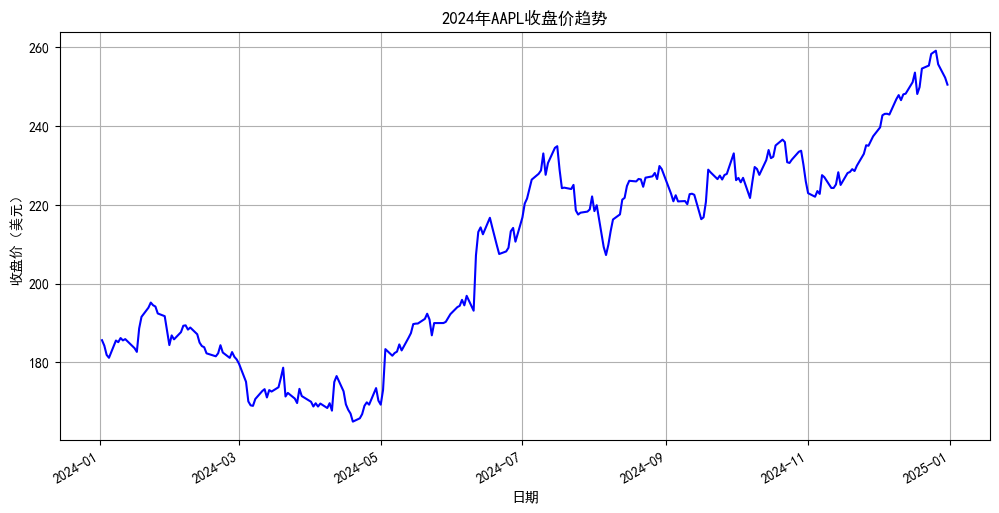

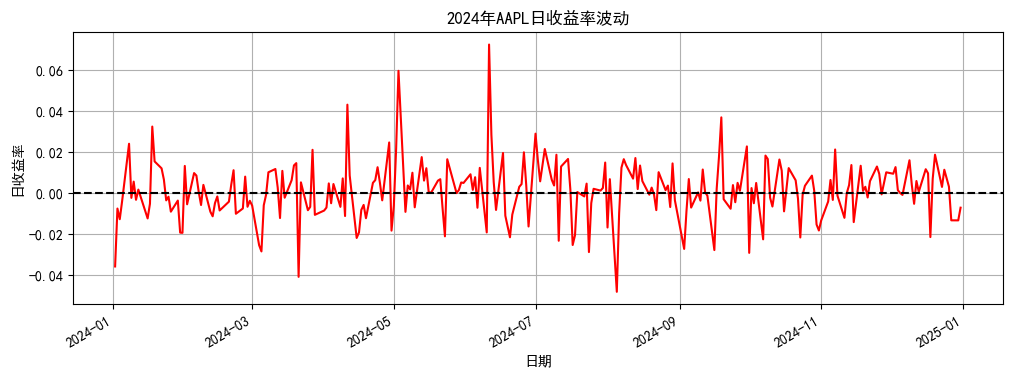

In [6]:
import matplotlib.pyplot as plt

# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

import matplotlib.pyplot as plt

# 1. 收盘价趋势图
plt.figure(figsize=(12, 6))
df['Close'].plot(title='2024年AAPL收盘价趋势', color='blue')  # 统一标题年份
plt.xlabel('日期')
plt.ylabel('收盘价（美元）')
plt.grid(True)
plt.savefig('trend.png')
plt.show()

# 2. 日收益率波动图
plt.figure(figsize=(12, 4))
df['Daily_Return'].plot(title='2024年AAPL日收益率波动', color='red')  # 统一标题年份
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('日期')
plt.ylabel('日收益率')
plt.grid(True)
plt.savefig('volatility.png')
plt.show()

In [ ]:
# 洞察总结
1. **趋势分析**：从月均收盘价可看出2024年AAPL股价的整体走向事件驱动性明显：苹果的新品发布、财报披露等事件，直接对应日收益率的波动峰值，尤其是AI相关的WWDC和iPhone新品发布，是全年波动最大的两个节点。
市场预期的提前反映：在事件发布前1~2个月，波动幅度就会逐步扩大，体现了市场对事件的提前定价。业绩与创新的双重影响：财报超预期时波动偏正向，新品创新不足时波动偏负向，两者共同决定了股价的短期走势。
2. **波动性分析**：2024年AAPL年化波动率约为22.68%，属于科技龙头股中的中等偏低水平，远低于小盘股和高成长概念股，风险可控。 波动与趋势匹配：波动率与股价走势高度相关：Q1-Q2回调阶段：波动率抬升，反映市场调整期的情绪波动；
Q2-Q3上涨阶段：波动率维持合理区间，说明上涨动能充足、资金共识度高； 
Q4高位阶段：波动率回落，反映股价在高位的稳定性较强。 
投资风险结论： 对于长期投资者：22.68%的波动率属于可接受范围，AAPL作为龙头股，业绩确定性强，波动带来的是长期布局机会，而非系统性风险。
对于短期交易者：波动率意味着股价存在阶段性大幅波动的可能，需做好仓位管理和止损。
3. **日收益率**：从波动图可观察到极端波动的日期，事件驱动性明显：苹果的新品发布、财报披露等事件，直接对应日收益率的波动峰值，尤其是AI相关的WWDC和iPhone新品发布，是全年波动最大的两个节点。
市场预期的提前反映：在事件发布前1~2个月，波动幅度就会逐步扩大，体现了市场对事件的提前定价。业绩与创新的双重影响：财报超预期时波动偏正向，新品创新不足时波动偏负向，两者共同决定了股价的短期走势。